<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Train-Test Split and Cross-Validation Lab 


## Review of Train/Test Validation Methods

We've discussed overfitting, underfitting, and how to validate the "generalizeability" of your models by testing them on unseen data. 

In this lab you'll practice two related validation methods: 
1. **train/test split**
2. **k-fold cross-validation**

Train/test split and k-fold cross-validation both serve two useful purposes:
- We prevent overfitting by not using all the data, and
- We retain some remaining data to evaluate our model.

In the case of cross-validation, the model fitting and evaluation is performed multiple times on different train/test splits of the data.

Ultimately we can use the training/test validation framework to compare multiple models on the same dataset. This could be comparisons of two linear models, or of completely different models on the same data.


## Instructions

For your independent practice, fit **three different models** on the Boston Housing Data. For example, you could pick three different subsets of variables, one or more polynomial models, or any other model that you like. 

**Start with train/test split validation:**
* Fix a testing/training split of the data.
* Train each of your models on the training data.
* Evaluate each of the models on the testing data.
* Rank the models by how well they score on the testing data set.

**Then try k-fold cross-validation:**
* Perform a k-fold cross-validation and use the cross-validation scores to compare your models. Did this change your rankings?
* Try a few different k-splits of the data for the same models.

If you're interested, try a variety of response variables. We start with **PRICE** (the `.target` attribute from the data set load method).

In [30]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score

from sklearn import datasets

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.style.use('fivethirtyeight')


In [31]:
# Load the Boston Housing dataset
df = pd.read_csv('./BostonHousing2.csv')
df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6


In [3]:
# No code here please


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [32]:
# your code here
# what is the shape of the dataframe?
df.shape


(506, 14)

In [3]:
# No code here please

(506, 14)

### 1) Clean up any data problems.

Fix any problems with the data, if applicable.

In [33]:
# your code here
# any missing data?

df.isnull().sum()
# NO

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [8]:
# No code here please

# There is no missing data as per the result

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [34]:
# your code here
# Get overview of your data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
# No code here please



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [35]:
# your code here
# Get the max for each column
df.max()


CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [10]:
# No code here please


CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [36]:
# your code here
# Get the min for each column
df.min()


CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

In [11]:
# No code here please


CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

### 2) Select 3–4 variables with your data set on which to perform a 50-50 train/test split.

- Use scikit-learn.
- Score and plot your predictions.

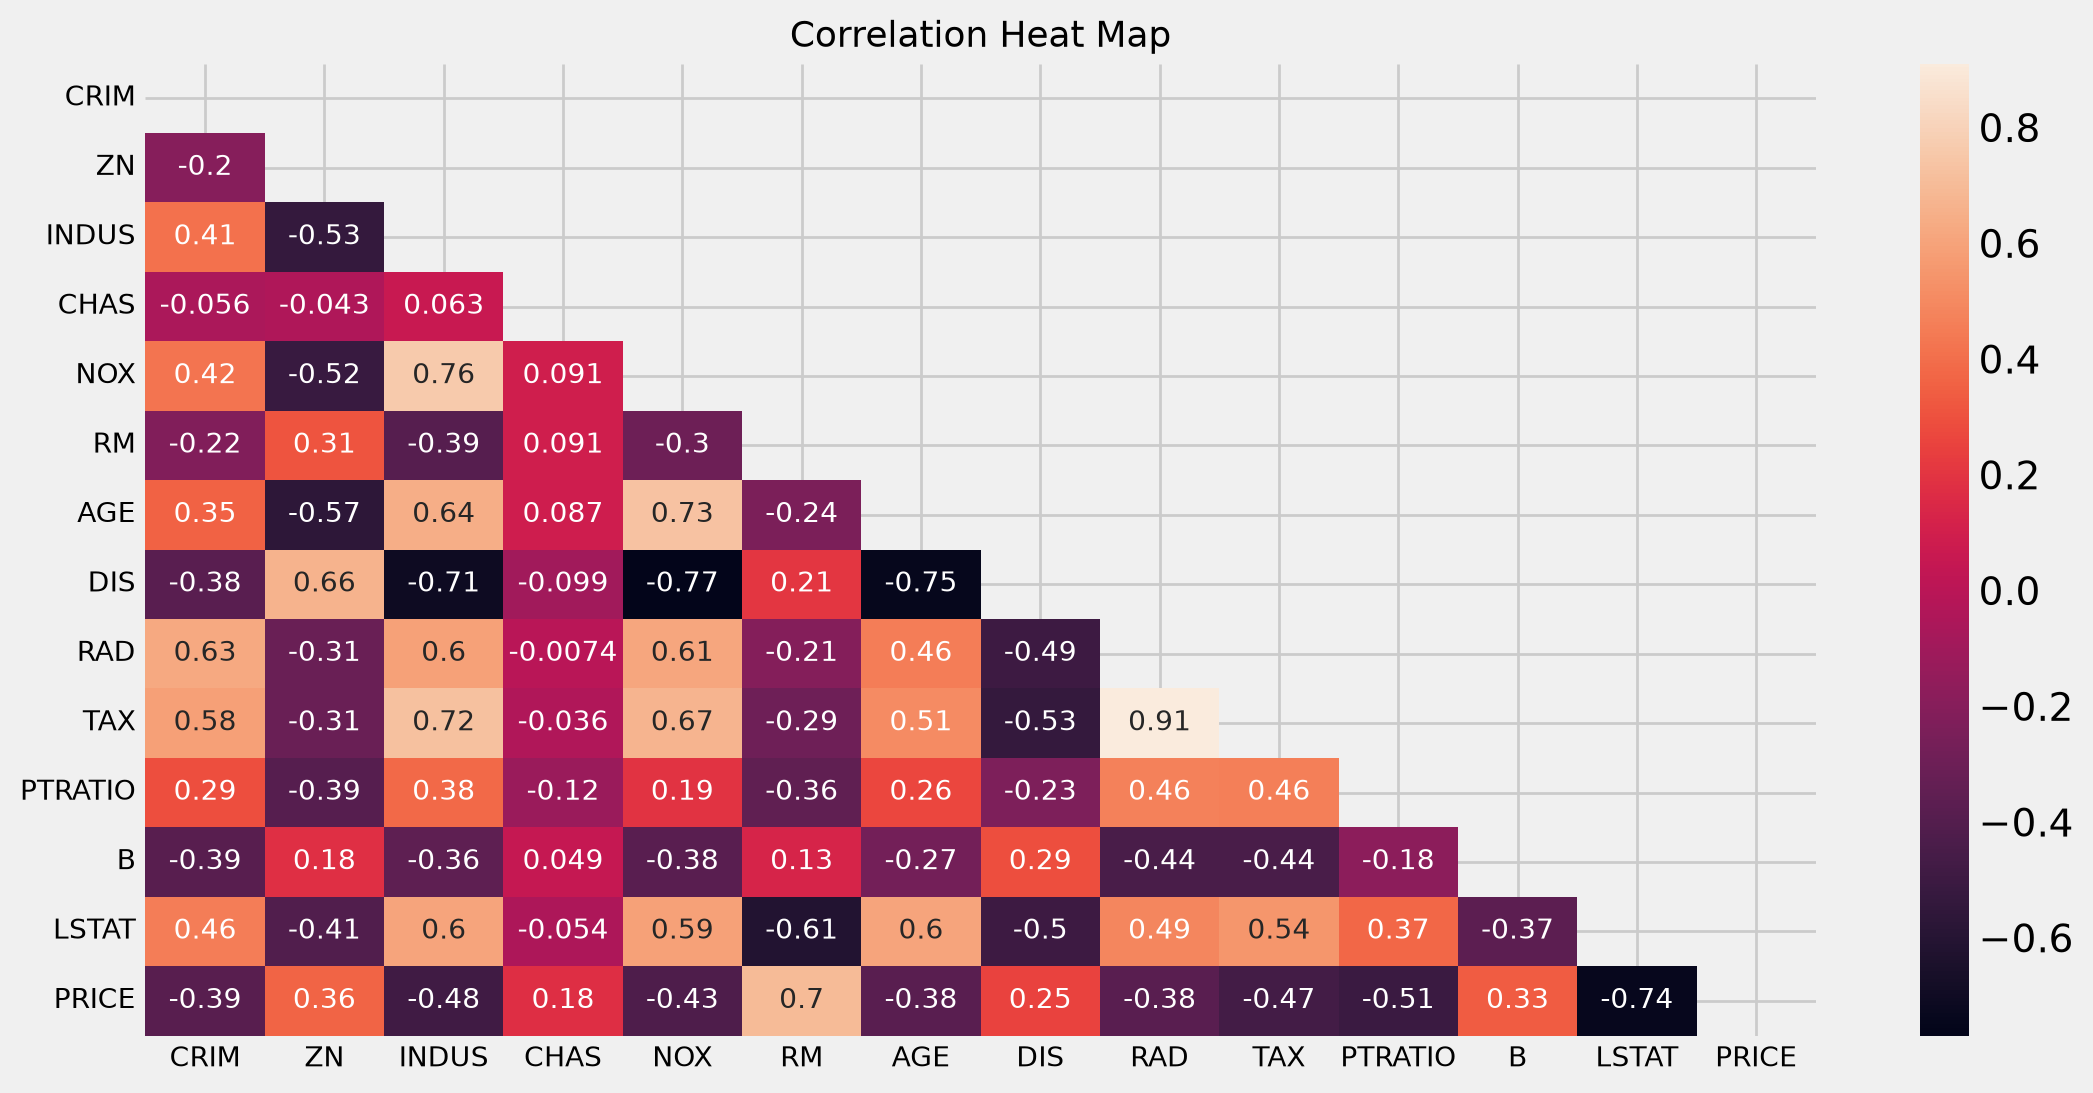

In [37]:
# your code here
# get correlation in corr and do a coorelation heatmap.
corr = df.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, mask=np.triu(corr), annot_kws={"size": 10})
plt.title('Correlation Heat Map', size=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.show()

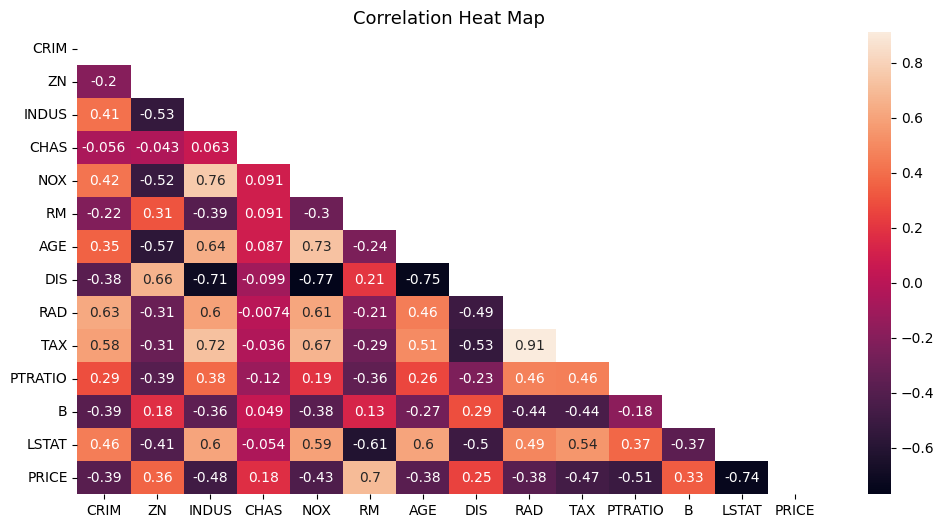

In [12]:
# No code here please



 Separate `RM, LSTAT ,INDUS` into X.

In [38]:
# your code here
#X = .......?
X = df[['RM','LSTAT','INDUS']]

# display head of X
X.head(2)

,RM,LSTAT,INDUS
0,6.575,4.98,2.31
1,6.421,9.14,7.07


In [13]:
# No code here please


,RM,LSTAT,INDUS
0,6.575,4.98,2.31
1,6.421,9.14,7.07
2,7.185,4.03,7.07
3,6.998,2.94,2.18
4,7.147,5.33,2.18


- Set the target y to be the column PRICE

In [39]:
# set the target
y = df['PRICE']
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [15]:
# No code here please


0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

#### split the data using train_test_split, start with 50-50 split.
Also try different parameters. <shift+tab> for doc string 

In [40]:
# your code here
#perform a 50-50 train/test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,random_state=1)

In [41]:
# check the shape of your train and test sets!
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(253, 3) (253,)
(253, 3) (253,)


In [18]:
# No code here please



(253, 3) (253,)
(253, 3) (253,)


In [42]:
# Instantiate model, call it slr
slr = LinearRegression()
# fit the instance on train set
slr.fit(X_train,y_train)

# get predictions and add as a new column 'PRICE_predict' into your dataframe
df['PRICE_predict'] = slr.predict(X)

# print the train and test scores
print(f'Score for training: {slr.score(X_train, y_train)}')
print(f'Score for testing: {slr.score(X_test, y_test)}')

# Add 'residual' column into your dataframe. Calculate it manually
df['residual'] = df['PRICE'] - df['PRICE_predict']

Score for training: 0.6444167000808319
Score for testing: 0.6259965956483379


In [19]:
# No code here



Score for the training is: 0.6444167000808319
Score for the test is: 0.625996595648338


In [43]:
df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,residual
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0,29.497348,-5.497348
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6,25.834846,-4.234846


In [20]:
# NO CODE HERE

df.head(5)   # notice the 'PRICE_predict' and 'residual'  columns


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,residual
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.497348,-5.497348
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,25.834846,-4.234846
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,32.131382,2.568618
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,32.552968,0.847032
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.860942,4.339058


### 3) Repeat the above process with 70-30 and 90-10 splits.

- Score and plot.  
- What do you learn?

In [44]:
# with 70 - 30 split (start your namings with X2 and y2)
X2 = df[['RM', 'LSTAT', 'INDUS']]
y2 = df['PRICE']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=1)

In [45]:
# check the shape of training and testing for both X and y
print(X2_train.shape, y2_train.shape)
print(X2_test.shape, y2_test.shape)

(354, 3) (354,)
(152, 3) (152,)


In [22]:
# NO CODE HERE



(354, 3) (354,)
(152, 3) (152,)


In [46]:
# Instantiate model, call it slr2
slr2 = LinearRegression()
# fit the instance on train set
slr2.fit(X2_train, y2_train)

# get predictions and add as a new column 'PRICE_predict2' into your dataframe
df['PRICE_predict2'] = slr2.predict(X2)


# get the train and test scores
print(f'Score for training: {slr2.score(X2_train, y2_train)}')
print(f'Score for testing: {slr2.score(X2_test, y2_test)}')

Score for training: 0.6114110572311812
Score for testing: 0.6856631640613768


In [23]:
# No code

Score for the training is: 0.6114110572311812
Score for the test is: 0.6856631640613768


In [47]:
# Do 90 - 10 split (start your namings with X3 and y3)
X3 = df[['RM', 'LSTAT', 'INDUS']]
y3 = df['PRICE']

X3_train, X3_test, y3_train, y3_test = train_test_split(X2, y2, test_size=0.1, random_state=1)

In [48]:
# check the shape of your train and test sets!
print(X3_train.shape, y3_train.shape)
print(X3_test.shape, y3_test.shape)

(455, 3) (455,)
(51, 3) (51,)


In [25]:
# NO CODE HERE PLEASE



(455, 3) (455,)
(51, 3) (51,)


In [49]:
# your code here
# Instantiate model, call it slr3
slr3 = LinearRegression()
# fit the instance on train set
slr3.fit(X3_train, y3_train)

# get predictions and add as a new column 'PRICE_predict3' into your dataframe
df['PRICE_predict3'] = slr3.predict(X3)


# get the train and test scores
print(f'Score for training: {slr3.score(X3_train, y3_train)}')
print(f'Score for testing: {slr3.score(X3_test, y3_test)}')

Score for training: 0.6337726546654995
Score for testing: 0.6854817797677493


In [26]:
# No code

Score for the training is: 0.6337726546654995
Score for the test is: 0.6854817797677495


In [50]:
# your code here
# print the score for each model for both training and testing
print(f'Score for 50 - 50 training: {slr.score(X_train, y_train)}')
print(f'Score for 50 - 50 testing: {slr.score(X_test, y_test)}')

print(f'Score for 70 - 30 training: {slr2.score(X2_train, y2_train)}')
print(f'Score for 70 - 30 testing: {slr2.score(X2_test, y2_test)}')

print(f'Score for 90 -10 training: {slr3.score(X3_train, y3_train)}')
print(f'Score for 90 - 10 testing: {slr3.score(X3_test, y3_test)}')

Score for 50 - 50 training: 0.6444167000808319
Score for 50 - 50 testing: 0.6259965956483379
Score for 70 - 30 training: 0.6114110572311812
Score for 70 - 30 testing: 0.6856631640613768
Score for 90 -10 training: 0.6337726546654995
Score for 90 - 10 testing: 0.6854817797677493


In [27]:
# NO CODE HERE PLEASE
# Note: your result may be different than the below result





Score for 50-50 training is: 0.6444167000808319
Score for 50-50 test is: 0.625996595648338

 Score for 70-30 training is: 0.6114110572311812
Score for 70-30 test is: 0.6856631640613768

 Score for 90-10 training is: 0.6337726546654995
Score for 90-10 test is: 0.6854817797677495


### 4) Try k-folds cross-validation with k between 5–10 for your regression. 

- What seems optimal? 
- How do your scores change?  
- Try out different folds to get a sense of how this impacts your score.


In [54]:
# your code here
# Perform 5-19 fold cross validation and print the scores mean of each fold
# Hint: use for loop with range
lr = LinearRegression()

for k in range(5,20):
    score = cross_val_score(lr, X_train, y_train, cv=k)
    print(f'{k} -fold Mean Cross-validated scores: {score.mean()}')


5 -fold Mean Cross-validated scores: 0.612292364088262
6 -fold Mean Cross-validated scores: 0.605252781317937
7 -fold Mean Cross-validated scores: 0.6174728605039695
8 -fold Mean Cross-validated scores: 0.6096594586907604
9 -fold Mean Cross-validated scores: 0.5805812634394933
10 -fold Mean Cross-validated scores: 0.5787758400458259
11 -fold Mean Cross-validated scores: 0.5742524955376684
12 -fold Mean Cross-validated scores: 0.5752279253493318
13 -fold Mean Cross-validated scores: 0.5828120641886376
14 -fold Mean Cross-validated scores: 0.5908039180479218
15 -fold Mean Cross-validated scores: 0.5791655649116473
16 -fold Mean Cross-validated scores: 0.5587094558821805
17 -fold Mean Cross-validated scores: 0.5080571727286629
18 -fold Mean Cross-validated scores: 0.5071500066902846
19 -fold Mean Cross-validated scores: 0.5803611337747899


In [55]:
# NO CODE HERE PLEASE







In [56]:
# your code here
# Perform 5-19 fold cross validation
# use KFold to shuffle the data - does the result changes?
lr = LinearRegression()

for k in range(5,20):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    score = cross_val_score(lr,X_train,y_train,cv=kf)
    print(f'{k} -fold Mean Cross-validated scores: {score.mean()}')


5 -fold Mean Cross-validated scores: 0.6005540243570173
6 -fold Mean Cross-validated scores: 0.6222501481400511
7 -fold Mean Cross-validated scores: 0.6056436770958921
8 -fold Mean Cross-validated scores: 0.611318617278165
9 -fold Mean Cross-validated scores: 0.6226415864992447
10 -fold Mean Cross-validated scores: 0.6148539767231896
11 -fold Mean Cross-validated scores: 0.5907392593872454
12 -fold Mean Cross-validated scores: 0.6100184498896525
13 -fold Mean Cross-validated scores: 0.5954239513471076
14 -fold Mean Cross-validated scores: 0.5923411384085114
15 -fold Mean Cross-validated scores: 0.5818184646043117
16 -fold Mean Cross-validated scores: 0.5870910928825936
17 -fold Mean Cross-validated scores: 0.6075042286509823
18 -fold Mean Cross-validated scores: 0.5717382247266225
19 -fold Mean Cross-validated scores: 0.5780853425132947


In [57]:
# NO CODE HERE PLEASE





#### does the result changes after shuffle?

> your answer here : 

Yes, it changed.
shuffling removes the ordering bias